In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
loan_df=pd.read_csv('loan_updated1.csv')
txn_df=pd.read_csv('Transactn1.csv')
dti_df=pd.read_csv('DT_Bucket.csv')
credit_df=pd.read_csv('Credit_transactn.csv')

In [78]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          5000 non-null   object 
 1   Customer_ID      5000 non-null   object 
 2   Loan_Type        5000 non-null   object 
 3   Sanction_Amount  5000 non-null   int64  
 4   Interest_Rate    5000 non-null   float64
 5   Tenure_Months    5000 non-null   int64  
 6   EMI              5000 non-null   float64
 7   Loan_Status      5000 non-null   object 
 8   Branch           5000 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 351.7+ KB


In [80]:
loan_df['Interest_Rate'].describe()

count    5000.000000
mean       11.458398
std         2.638457
min         7.000000
25%         9.140000
50%        11.480000
75%        13.730000
max        16.000000
Name: Interest_Rate, dtype: float64

In [62]:
txn_df.head()

,Transaction_ID,Customer_ID,Branch,Transaction_Date,Transaction_Type,Amount,Currency,Status,Amount_in_INR
0,TXN833420,CUST2665,TRIVANDRUM,2023-01-07,DEPOSIT,389650.0,INR,UNKNOWN,389650.0
1,TXN659381,CUST9640,CHENNAI,2019-01-12,WITHDRAWAL,3793001.0,USD,PENDING,314819083.0
2,TXN880101,CUST3248,CALICUT,2018-01-16,WITHDRAWAL,2160839.0,INR,UNKNOWN,2160839.0
3,TXN823601,CUST2120,KOCHI,2020-12-18,WITHDRAWAL,1180522.0,USD,SUCCESS,97983326.0
4,TXN318577,CUST2707,TRIVANDRUM,2021-09-20,WITHDRAWAL,4326846.0,INR,PENDING,4326846.0


In [5]:
loan_df['Loan_Type'].unique()

array(['Auto Loan', 'Home Loan', 'Business Loan', 'Personal Loan'],
      dtype=object)

In [9]:
loan_df['Loan_Type'].value_counts()

Loan_Type
Business Loan    1297
Home Loan        1266
Personal Loan    1219
Auto Loan        1218
Name: count, dtype: int64

In [13]:
#creating product exposure and total expoxure and product exposure percent
exposure=loan_df.groupby('Loan_Type')['Sanction_Amount'].sum()
Total=exposure.sum()
percent_exp=(exposure / Total * 100).round(2)


#summary dataframe
summary=pd.DataFrame({
    'Exposure':exposure,
    'Percent of Total':percent_exp,
}).sort_values(by='Exposure',ascending=False)

print(summary)

                 Exposure  Percent of Total
Loan_Type                                  
Business Loan  6518314591             25.66
Home Loan      6453019575             25.40
Personal Loan  6330548163             24.92
Auto Loan      6101450312             24.02


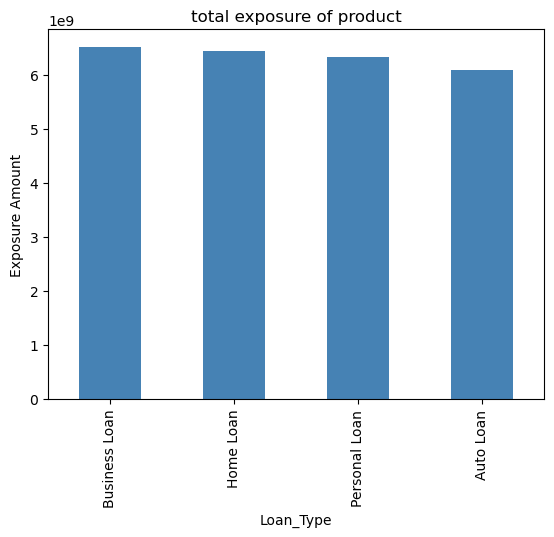

In [87]:
#bar plot
summary['Exposure'].plot(kind='bar',color='steelblue',title='total exposure of product')
plt.ylabel('Exposure Amount')
plt.show()

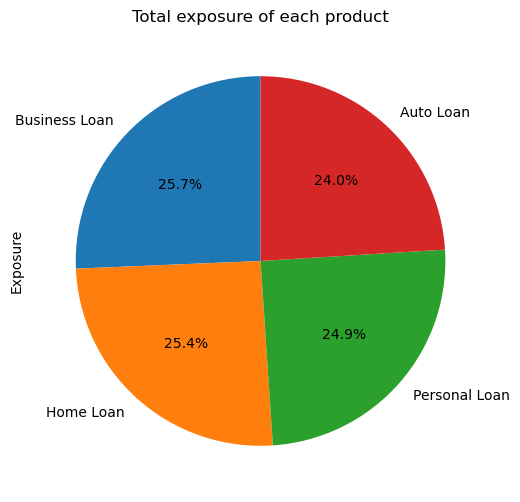

In [97]:
#Pie Chart
summary['Exposure'].plot(kind='pie',autopct='%1.1f%%',figsize=(6,6),startangle=90)
plt.title('Total exposure of each product')
plt.show()

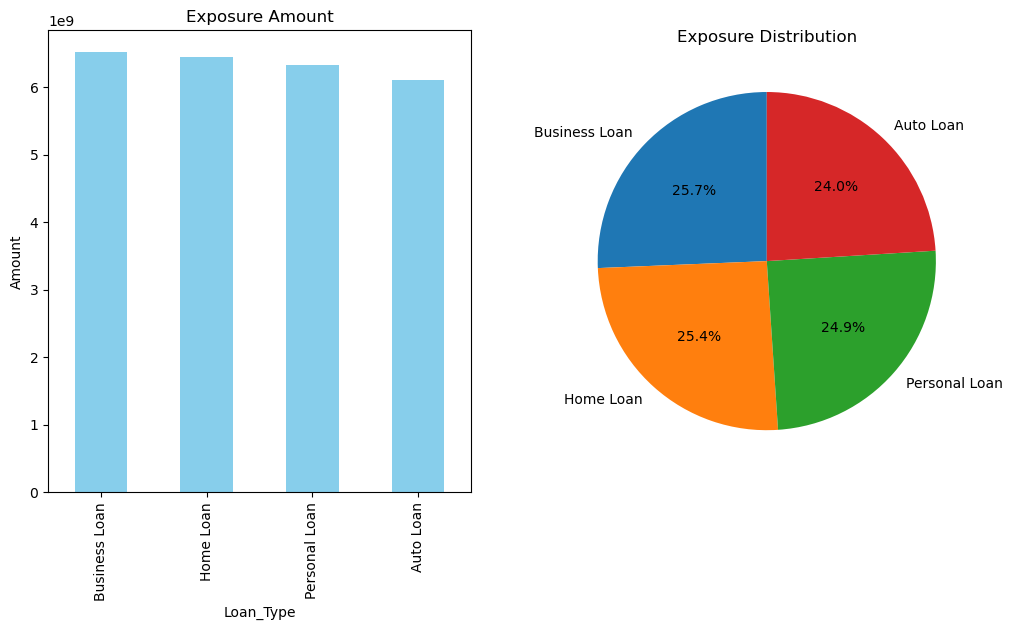

In [99]:
#like a dashboard
fig,axes=plt.subplots(1,2,figsize=(12,6))

#bar plot
summary['Exposure'].plot(kind='bar',ax=axes[0],color='skyblue')
axes[0].set_title('Exposure Amount')
axes[0].set_ylabel('Amount')

#pie chart
summary['Exposure'].plot(kind='pie',ax=axes[1],autopct='%1.1f%%',startangle=90)
axes[1].set_title('Exposure Distribution')
axes[1].set_ylabel('')

plt.show()




In [15]:
#loan exposure
loan_exp=loan_df.groupby('Loan_Type').agg(
    total_exposure=('Sanction_Amount','sum'),
    avg_loan_amnt=('Sanction_Amount','mean'),
    customer_count=('Customer_ID','count')
)

print(loan_exp)

               total_exposure  avg_loan_amnt  customer_count
Loan_Type                                                   
Auto Loan          6101450312   5.009401e+06            1218
Business Loan      6518314591   5.025686e+06            1297
Home Loan          6453019575   5.097172e+06            1266
Personal Loan      6330548163   5.193231e+06            1219


In [72]:
#loan exposure by loan type and status
df_txn_loan=loan_df.merge(txn_df[['Customer_ID','Transaction_Type','Transaction_Date','Status','Amount_in_INR']],on='Customer_ID',how='left')

df_txn_loan=df_txn_loan.dropna()

#df_txn_loan.info()

txn_loan_df=df_txn_loan.groupby(['Loan_Type','Status']).agg(
    Exposure=('Sanction_Amount','sum'),
    Transaction_value=('Amount_in_INR','sum'),
    Transactions=('Status','count')
).reset_index()

print(txn_loan_df)


        Loan_Type   Status    Exposure  Transaction_value  Transactions
0       Auto Loan   FAILED  2205627006       2.331362e+10           440
1       Auto Loan  PENDING  2077878025       1.809414e+10           388
2       Auto Loan  SUCCESS  3985567531       3.779812e+10           791
3       Auto Loan  UNKNOWN  2022468310       2.316099e+10           413
4   Business Loan   FAILED  2052083893       1.907876e+10           413
5   Business Loan  PENDING  2247839861       1.658297e+10           446
6   Business Loan  SUCCESS  4239644024       3.822544e+10           836
7   Business Loan  UNKNOWN  2249581182       1.656901e+10           438
8       Home Loan   FAILED  2171551828       2.234095e+10           430
9       Home Loan  PENDING  2410488506       1.552667e+10           433
10      Home Loan  SUCCESS  4357635919       3.884231e+10           837
11      Home Loan  UNKNOWN  2236696636       2.040081e+10           435
12  Personal Loan   FAILED  2377511021       1.991809e+10       

                         Total_Sanction_Amount  Loan_count     Avg_DTI  \
Loan_Type     DTI_Risk                                                   
Auto Loan     High                   952799764         185   80.466270   
              Low                    575511693         193   16.584301   
              Moderate              1011598818         203   44.759852   
              Very High             3561540037         637  323.473830   
Business Loan High                  1010946351         194   79.118402   
              Low                    557894838         210   15.434143   
              Moderate               975813016         193   45.194404   
              Very High             3973660386         700  336.563457   
Home Loan     High                  1037669490         200   78.288750   
              Low                    557945854         192   16.375937   
              Moderate              1001221938         213   44.822207   
              Very High             38

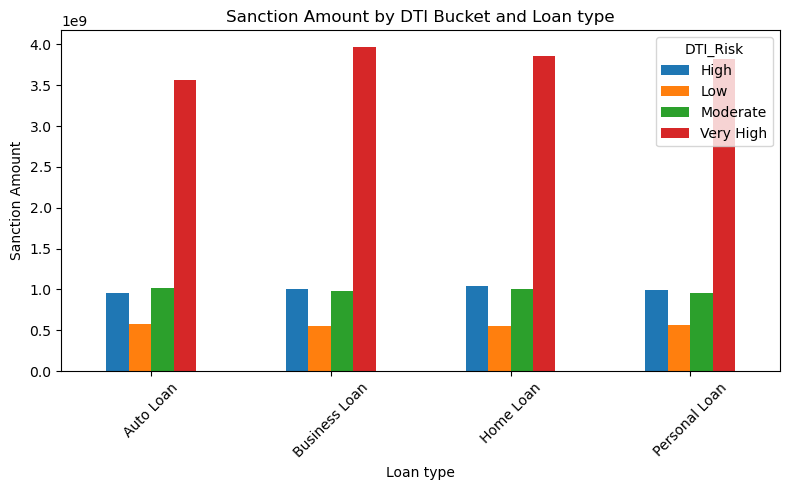

In [39]:
#loan exposure DTI segment

loan_dti=loan_df.merge(dti_df[['Customer_ID','DTI_Risk','DTI']],on='Customer_ID',how='left')
#print(loan_dti)
#loan_dti.info()


loan_risk=loan_dti.groupby(['Loan_Type','DTI_Risk']).agg(
    Total_Sanction_Amount=('Sanction_Amount','sum'),
    Loan_count=('Sanction_Amount','count'),
    Avg_DTI=('DTI','mean')
)

#loan_risk['txn_count']=loan_dti.groupby(['Loan_Type','DTI_Risk'])['Sanction_Amount'].count()

loan_risk['avg_sanction_amt']=loan_risk['Total_Sanction_Amount']/loan_risk['Loan_count']

print(loan_risk)
#visualise 

pivot_df=loan_risk.pivot_table(index='Loan_Type',columns='DTI_Risk',values='Total_Sanction_Amount')

pivot_df.plot(kind='bar',figsize=(8,5))

plt.title('Sanction Amount by DTI Bucket and Loan type')
plt.xlabel('Loan type')
plt.ylabel('Sanction Amount')
plt.legend(title='DTI_Risk')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

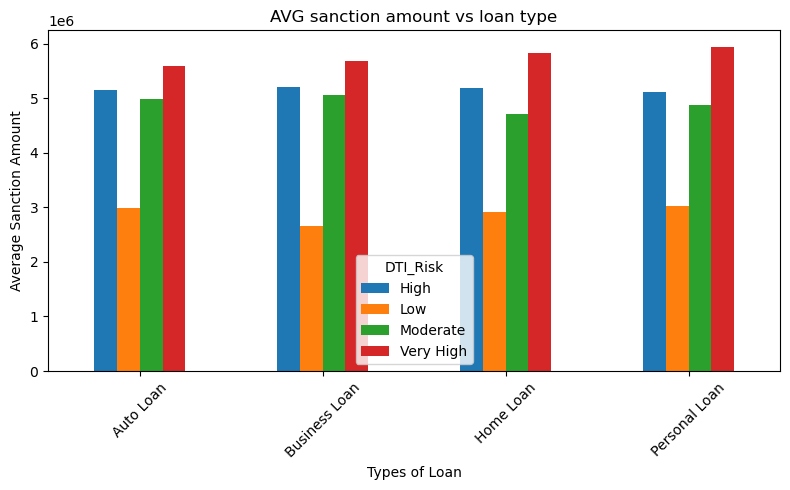

In [9]:
#visualise 

pivot_df1=loan_risk.pivot_table(index='Loan_Type',columns='DTI_Risk',values='avg_sanction_amt')

pivot_df1.plot(kind='bar',figsize=(8,5))
plt.xlabel('Types of Loan')
plt.ylabel('Average Sanction Amount')
plt.title('AVG sanction amount vs loan type')
plt.xticks(rotation=45)
plt.legend(title='DTI_Risk')

plt.tight_layout()
plt.show()

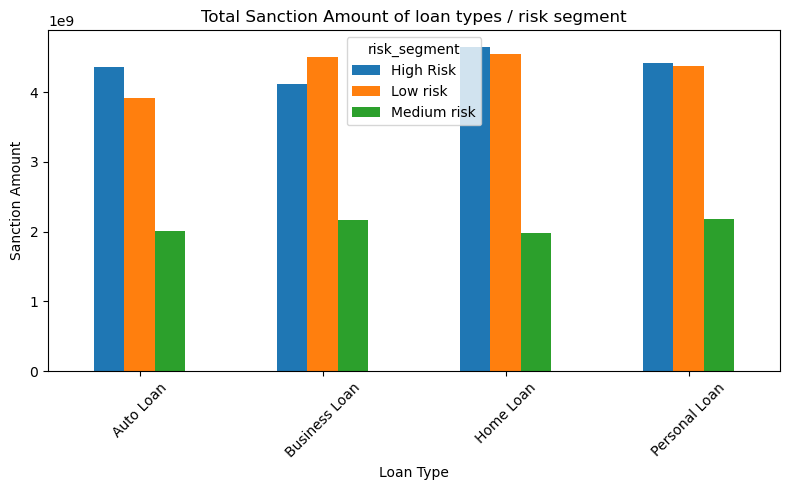

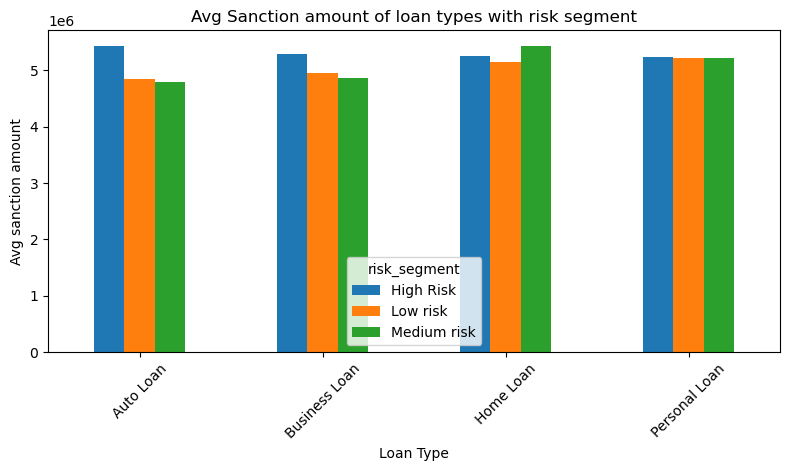

In [27]:
#loan Credit segment

credit_df=credit_df.rename(columns={'customer_id':'Customer_ID'})

loan_credit=loan_df.merge(credit_df[['Customer_ID','risk_segment']],on='Customer_ID',how='left')


credit_risk=loan_credit.groupby(['Loan_Type','risk_segment']).agg(
    Total_Sanction_amt=('Sanction_Amount','sum'),
    loan_count=('Sanction_Amount','count')
)

credit_risk['avg_sanction_amt']=credit_risk['Total_Sanction_amt']/credit_risk['loan_count']




#visualising total sanction amt of loan types based on credit risk segment

pivot_df2=credit_risk.pivot_table(index='Loan_Type',columns='risk_segment',values='Total_Sanction_amt')

pivot_df2.plot(kind='bar',figsize=(8,5))
plt.xlabel('Loan Type')
plt.ylabel('Sanction Amount')
plt.title('Total Sanction Amount of loan types / risk segment')
plt.legend(title='risk_segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#avg sanction amount per loan types

pivot_df2=credit_risk.pivot_table(index='Loan_Type',columns='risk_segment',values='avg_sanction_amt')

pivot_df2.plot(kind='bar',figsize=(8,5))
plt.xlabel('Loan Type')
plt.ylabel('Avg sanction amount')
plt.title('Avg Sanction amount of loan types with risk segment')
plt.legend(title='risk_segment')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

Conclusion:

~As larger loan exposure concentrated on High DTI and Low Credit score customers ~ indicates Elevated Credit exposure risk
~Institution heavily exposed to weak credit-quality borrowers 
~Large Loans exposure concentrated on to financially stressed customers ~ gradually will elevate default risk 

In [56]:
#Utilization ratio

uti_data=credit_df.merge(loan_df[['Customer_ID','Loan_Type','Sanction_Amount']],on='Customer_ID',how='left')

uti_data['Utilisation_ratio']=uti_data['amount_in_inr']/uti_data['Sanction_Amount']


utilization=uti_data.groupby('Loan_Type')['Utilisation_ratio'].mean().reset_index()

print(utilization)

       Loan_Type  Utilisation_ratio
0      Auto Loan          26.089980
1  Business Loan          22.084499
2      Home Loan          20.307831
3  Personal Loan          14.865518


In [ ]:
#Default rate